In [45]:
""" Imports """
%load_ext autoreload
%autoreload 2
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import hex2color
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
""" Image functions """
def plot_image_grid(images_data, fig, axes):
    for item in images_data:
        row = item['row']
        col = item['col']
        image = item['image']
        title = item.get('title', '')
        cmap = item.get('cmap', 'gray')
        
        if axes.ndim == 1:
            ax = axes[col]
        else:
            ax = axes[row, col]

        if title:
            ax.set_title(title, pad=0, fontsize=14)
            
        if isinstance(image, torch.Tensor):
            image = image.detach().cpu().numpy()
            
        ax.imshow(image, cmap=cmap)
        ax.axis('off')

def get_original_images(samples, labels, channels, start_row, title="Original Timepoint"):
    images_data = []
    for j, sample in enumerate(samples):
        images = sample.squeeze()
        
        if images.ndim == 2:
            images_data.append({
                'image': images,
                'title': f"{title} {labels[j]}",
                'row': start_row,
                'col': j
            })
        elif images.ndim == 3:
            for i, image in enumerate(images):
                title = f"{title} {labels[j]}" if i == 0 else ""
                images_data.append({
                    'image': image,
                    'title': title,
                    'row': start_row + i,
                    'col': j
                })
        else:
            raise ValueError("Unsupported image dimensions. Expected 2D or 3D images.")
            
    return images_data

def get_reconstructed_images(samples, model, channels, start_row, title="Predicted Timepoint"):
    images_data = []
    for j, sample in enumerate(samples):
        model.eval()
        sample_input = sample.unsqueeze(0)
        
        with torch.no_grad():
            result = model(sample_input)
            
        reconstructed_image, label_pred = result[:2]
        reconstructed_image = reconstructed_image.squeeze()
        label_pred = torch.max(label_pred, dim=1)[1].item()
        
        if reconstructed_image.ndim == 2:
            images_data.append({
                'image': reconstructed_image,
                'title': f"{title}",
                'row': start_row,
                'col': j
            })
        elif reconstructed_image.ndim == 3:
            for i, image in enumerate(reconstructed_image):
                title = f"{title} {label_pred}" if i == 0 else ""
                images_data.append({
                    'image': image,
                    'title': title,
                    'row': start_row + i,
                    'col': j
                })
        else:
            raise ValueError("Unsupported image dimensions. Expected 2D or 3D images.")
            
    return images_data

def get_difference_images(samples, model, channels, start_row, cmap="bwr"):
    imgs = []
    for j, sample in enumerate(samples):
        with torch.no_grad():
            recon, _ = model(sample.unsqueeze(0))[:2]
        recon, orig = recon.squeeze(), sample.squeeze()

        diffs = recon - orig
        if diffs.ndim == 2:
            diffs = diffs.unsqueeze(0)

        for ch_idx, diff in enumerate(diffs):
            m = diff.abs().max().item() or 1.0
            imgs.append(
                {
                    "image": diff,
                    "title": "",
                    "row": start_row + ch_idx,
                    "col": j,
                    "cmap": cmap,
                    "vmin": -m,
                    "vmax": m,
                }
            )
    return imgs

def get_saliency_maps(dataset, indices, model, start_row, title="Saliency Map"):
    images_data = []
    for j, idx in enumerate(indices):
        data = dataset[idx]
        input_tensor = data[0].unsqueeze(0)
        
        # Generate saliency map
        saliency_map = model.get_saliency_map(input_tensor).squeeze()
        
        images_data.append({
            'image': saliency_map,
            'title': f"{title}",
            'row': start_row,
            'col': j,
            'cmap': 'hot'
        })
        
    return images_data

""" Plotting functions """
def extract_seeds(all_loaders, loader_type):
    return {
        experiment: {
            dataset_name: [key.split('_')[-1] for key in datasets["full"].get_seed_keys(loader_type)]
            for dataset_name, datasets in models.items()
        }
        for experiment, models in all_loaders.items()
    }

def process_colors(experiment, dataset_name, seeds, timepoints):
    color_seeds = [int(seed) for seed in seeds[experiment][dataset_name]]
    color_timepoints = [int(timepoint) for timepoint in timepoints[experiment][dataset_name]]
    color_seeds_unique = list(set(color_seeds))
    return color_seeds, color_timepoints, color_seeds_unique

def plot_time_ordered_points(ax, embeddings, color_seeds, color_timepoints, title, xlabel, ylabel):
    selected_points = [(x, y) for k, (x, y) in enumerate(embeddings) if color_seeds[k] in color_seeds_unique]
    selected_timepoints = [color_timepoints[k] for k in range(len(color_seeds)) if color_seeds[k] in color_seeds_unique]

    if len(selected_points) > 1:
        # Ensure points are ordered by time
        sorted_indices = sorted(range(len(selected_timepoints)), key=lambda k: selected_timepoints[k])
        ordered_points = [selected_points[i] for i in sorted_indices]
        ordered_timepoints = [selected_timepoints[i] for i in sorted_indices]

        # Create line segments between consecutive points
        segments = [
            (ordered_points[i], ordered_points[i + 1]) for i in range(len(ordered_points) - 1)
        ]
        segment_colors = ordered_timepoints[:-1]
        norm = plt.Normalize(min(segment_colors), max(segment_colors))
        lc = LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(segment_colors)
        lc.set_linewidth(2)

        ax.add_collection(lc)
        ax.scatter(*zip(*ordered_points), c=ordered_timepoints, cmap='viridis', s=50)  # Optional to highlight points

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(lc, ax=ax, label='Timepoints')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Data Loading

In [53]:
study_name = "cae-custom-loss"
image_dir = "data"
num_timepoints = 15

results_dir = f"results/{study_name}"

all_models = load_models(results_dir, num_timepoints=num_timepoints, best_models_flag=True)
all_loaders = load_loaders(results_dir, image_dir)

all_samples = {}
all_labels = {}
data_loaders = {}
random_indices = {}

for dataset_name, loader in all_loaders.items():
    data_loaders[dataset_name] = {
        "train": loader.get_dataloader('train'),
        "test": loader.get_dataloader('test'),
        "full": loader,
    }
    
    loader_test_len = len(data_loaders[dataset_name]["test"].dataset)
    
    if dataset_name not in random_indices:
        random_indices[dataset_name] = np.random.choice(loader_test_len, 5, replace=False)
    
    indices = random_indices[dataset_name]
    all_samples[dataset_name] = []
    all_labels[dataset_name] = []
    
    for idx in indices:
        sample, label = data_loaders[dataset_name]["test"].dataset[idx]
        all_samples[dataset_name].append(sample)
        all_labels[dataset_name].append(label)
        
all_models = dict(sorted(all_models.items()))

print(f"Models: {list(all_models.keys())}")
print(f"Datasets: {list(all_loaders.keys())}")

Loading model cae_medium (8.70e+06 parameters)
Models: ['cae-medium']
Datasets: ['vf_256_processed_jpg']


## Image reconstruction

Model: cae_medium
Latent Dimension: 16
Optimizer: Adam (lr=0.0001, betas=[0.9, 0.999], type=Adam)
Image Size: 128
Loss Weights: {'image': 0.9, 'timepoint': 0.09999999999999998}
Encoder Parameters: 4,334,224
Decoder (Image) Parameters: 4,365,201
Decoder (Timepoint) Parameters: 3,855
Total Parameters: 8,703,280



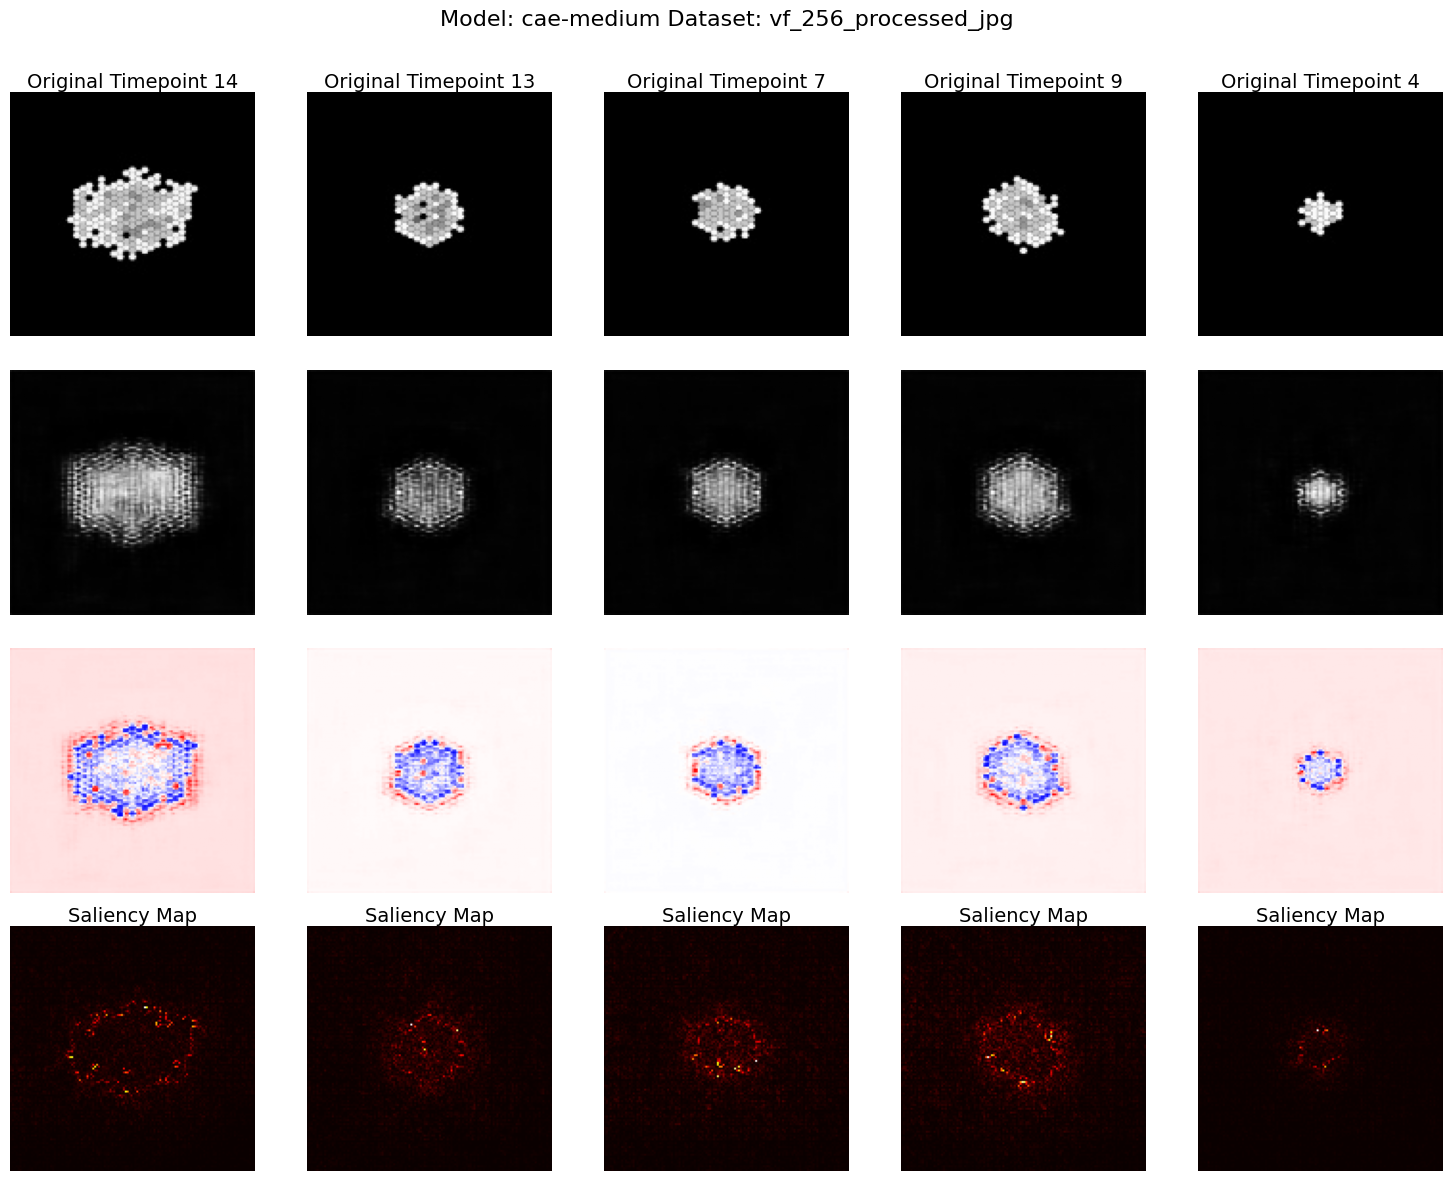

In [54]:
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        print(model)
        samples = all_samples[dataset_name]
        labels = all_labels[dataset_name]
        test_dataset = data_loaders[dataset_name]["test"].dataset
        channels = data_loaders[dataset_name]["full"].channels
        indices = random_indices[dataset_name]
        
        num_channels = len(channels)
        nrows = num_channels * 3 + 1  
        fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(15, 12))
        
        all_images_data = []
        
        original_images = get_original_images(samples, labels, channels, start_row=0)
        all_images_data.extend(original_images)
    
        recon_start_row = num_channels
        reconstructed_images = get_reconstructed_images(samples, model, channels, start_row=recon_start_row, title="")
        all_images_data.extend(reconstructed_images)
        
        diff_start_row = num_channels * 2
        difference_images = get_difference_images(
            samples, model, channels, start_row=diff_start_row
        )
        all_images_data.extend(difference_images)

        saliency_start_row = num_channels * 3
        saliency_maps = get_saliency_maps(
            test_dataset, indices, model, start_row=saliency_start_row
        )
        all_images_data.extend(saliency_maps)

        # for i in range(len(indices)):
        #     plt.imsave(f"figures/ARCADE/ARCADE_original_{model_name}_{i}.png", all_images_data[i]['image'], cmap='gray')
        #     plt.imsave(f"figures/ARCADE/ARCADE_reconstructed_{model_name}_{i}.png", all_images_data[i + 5]['image'], cmap='gray')
        #     plt.imsave(f"figures/ARCADE/ARCADE_difference_{model_name}_{i}.png", all_images_data[i + 10]['image'], cmap='bwr')
            
        plot_image_grid(all_images_data, fig, axes)
        fig.suptitle(f"Model: {model_name} Dataset: {dataset_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

In [55]:
random_images = {}
random_reconstructed_images = {}
processed_datasets = {}

for model_name, datasets in all_models.items():
    random_reconstructed_images[model_name] = {}
    for dataset_name, model in datasets.items():
        if dataset_name in processed_datasets:
            random_images[dataset_name] = processed_datasets[dataset_name]['random_images']
            random_reconstructed_images[dataset_name] = processed_datasets[dataset_name]['random_reconstructed_images']
        else:
            train_loader = data_loaders[dataset_name]["train"]
            test_loader = data_loaders[dataset_name]["test"]
            encoder = model.encoder
            last_layer = encoder[-1]
            dim = last_layer.out_features
            
            train_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in train_loader
            ]

            test_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in test_loader
            ]
            
            pca = PCA(n_components=dim)
            train_images_pca = pca.fit_transform(train_images)
            test_images_pca = pca.transform(test_images)
            reconstructed_test_images = pca.inverse_transform(test_images_pca)

            indices = random_indices[dataset_name]
            random_images_list = [test_images[i] for i in indices]
            random_reconstructed_images_list = [reconstructed_test_images[i] for i in indices]

            processed_datasets[dataset_name] = {
                'random_images': random_images_list,
                'random_reconstructed_images': random_reconstructed_images_list,
            }
            
            random_images[dataset_name] = random_images_list
            random_reconstructed_images[dataset_name] = random_reconstructed_images_list

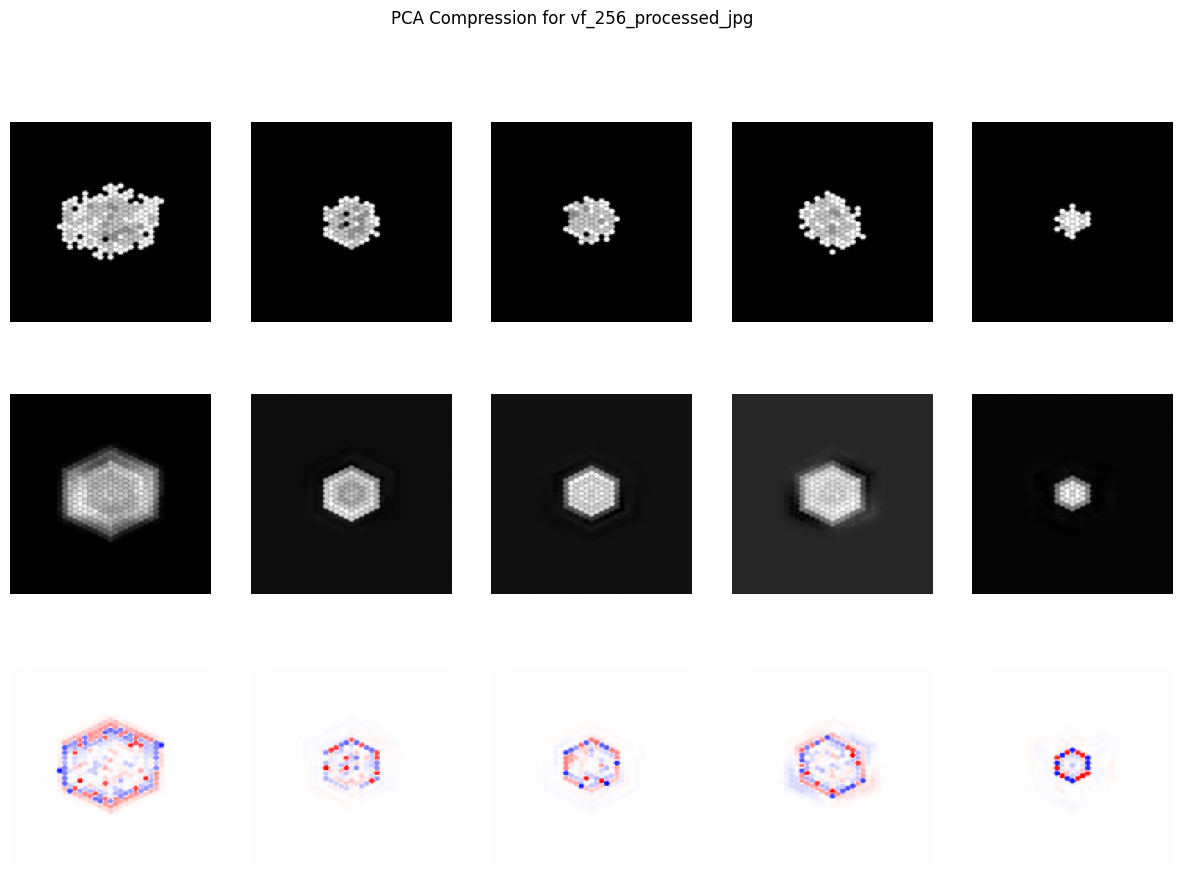

In [56]:
for dataset, _ in processed_datasets.items():
    reshaped_random_images = [
        img.reshape(num_channels, 128, 128) for img in random_images[dataset]
    ]
    reshaped_random_reconstructed_images = [
        img.reshape(num_channels, 128, 128) for img in random_reconstructed_images[dataset]
    ]

    nrows = num_channels * 3
    fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(15, 10))
    
    for j, sample in enumerate(reshaped_random_images):
        for i, image in enumerate(sample):
            axes[i, j].imshow(image, cmap='gray')
            axes[i, j].axis('off')

    for j, sample in enumerate(reshaped_random_reconstructed_images):
        for i, image in enumerate(sample):
            axes[num_channels + i, j].imshow(image, cmap='gray')
            axes[num_channels + i, j].axis('off')

    for j, (orig_sample, recon_sample) in enumerate(
        zip(reshaped_random_images, reshaped_random_reconstructed_images)):
        for i, (orig, recon) in enumerate(zip(orig_sample, recon_sample)):
            diff = recon - orig
            vmax = np.abs(diff).max() or 1.0        # symmetric limits
            axes[2 * num_channels + i, j].imshow(diff,
                                                cmap="bwr",
                                                vmin=-vmax,
                                                vmax=vmax)
            axes[2 * num_channels + i, j].axis("off")

    fig.suptitle(f"PCA Compression for {dataset}")
    plt.show()

## Traditional dimension reduction techniques

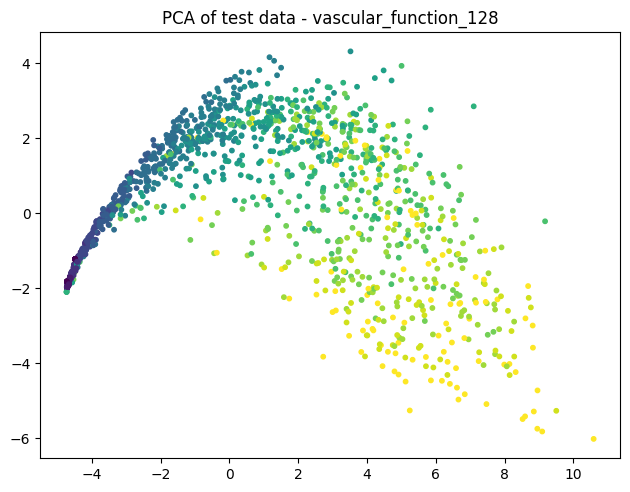

In [19]:
processed_pca = {}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        if dataset_name in processed_pca:
            continue  

        train_loader = data_loaders[dataset_name]["train"]
        test_loader = data_loaders[dataset_name]["test"]

        def flatten_images(loader):
            flat_images = []
            for batch in loader:
                imgs_batch = batch[0].squeeze()
                flat_imgs = [img.flatten() for img in imgs_batch]
                flat_images.append(np.concatenate(flat_imgs))
            return flat_images

        train_images = flatten_images(train_loader)
        test_images = flatten_images(test_loader)
        test_timepoints = [batch[1].item() for batch in test_loader]

        pca = PCA(n_components=2)
        train_images_pca = pca.fit_transform(train_images)
        test_images_pca = pca.transform(test_images)

        def plot_projection(projection, title):
            plt.scatter(projection[:, 0], projection[:, 1], label="test", c=test_timepoints, s=10)
            plt.tight_layout()
            plt.title(title)
            plt.show()

        plot_projection(test_images_pca, f"PCA of test data - {dataset_name}")

    break

## Visualization of the latent space

In [8]:
timepoints = defaultdict(lambda: defaultdict(list))

for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        
        loader = data_loaders[dataset_name]["full"]
        for idx in loader._test_indices:
            timepoints[model_name][dataset_name].append(int(loader._get_data_feature(idx, 'timepoint')))

In [9]:
nn_embeddings = {}

for model_name, datasets in all_models.items():
    nn_embeddings[model_name] = {}
    for dataset_name, model in datasets.items():
        nn_embeddings[model_name][dataset_name] = {}
        print(model_name, dataset_name)
            
        test_loader = data_loaders[dataset_name]["test"]
        num_dimensions = model.latent_dim

        model.eval()
        with torch.no_grad():
            encoded_samples = []
            for inputs, _ in test_loader:
                encoded_batch = model.encode(inputs)
                encoded_samples.append(encoded_batch)
            encoded_samples = torch.cat(encoded_samples, dim=0)

            mean = encoded_samples.mean(dim=0, keepdim=True)
            std = encoded_samples.std(dim=0, keepdim=True)
            normalized_embeddings = (encoded_samples - mean) / (std + 1e-8)

            nn_embeddings[model_name][dataset_name] = normalized_embeddings

conv-vae-small vascular_function_128


TypeError: expected Tensor as element 0 in argument 0, but got tuple

In [ ]:
pca_embeddings = {}
for model_name, dataset in nn_embeddings.items():
    pca_embeddings[model_name] = {}
    for dataset_name, embeddings in dataset.items():
        try:
            pca = PCA(n_components=2)
            pca_embeddings[model_name][dataset_name] = pca.fit_transform(embeddings)

            print(f"{model_name} | {dataset_name} - Explained Variance: {pca.explained_variance_ratio_}")
        except ValueError:
            print(f"Skipping {model_name} PCA")

ae-medium | vascular_function_128 - Explained Variance: [0.4823408  0.20072674]
ae-small | vascular_function_128 - Explained Variance: [0.4907205  0.16692055]


ae-medium


/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_75302/1257011061.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


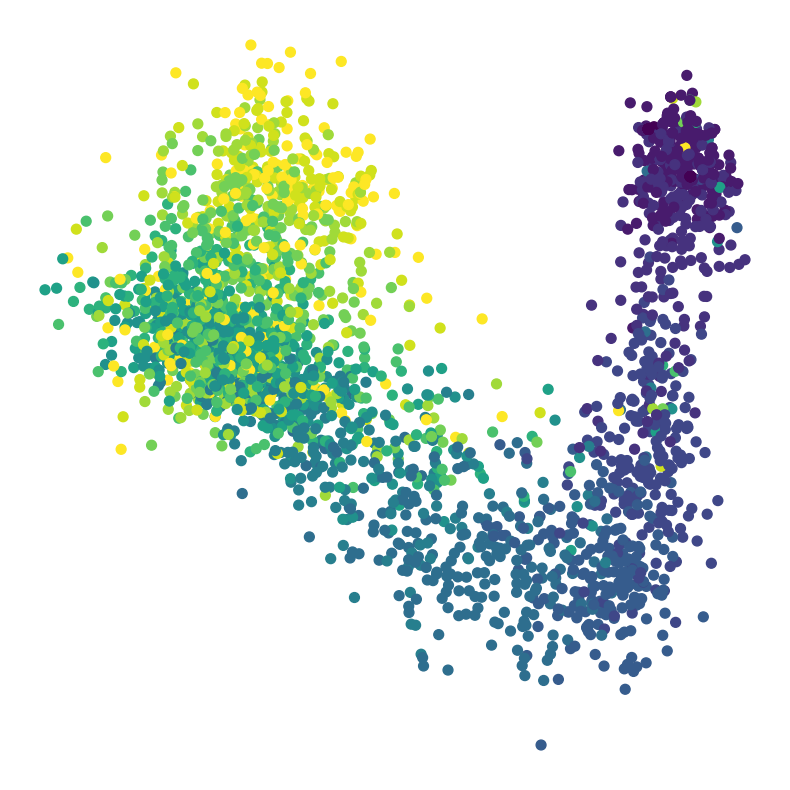

ae-small


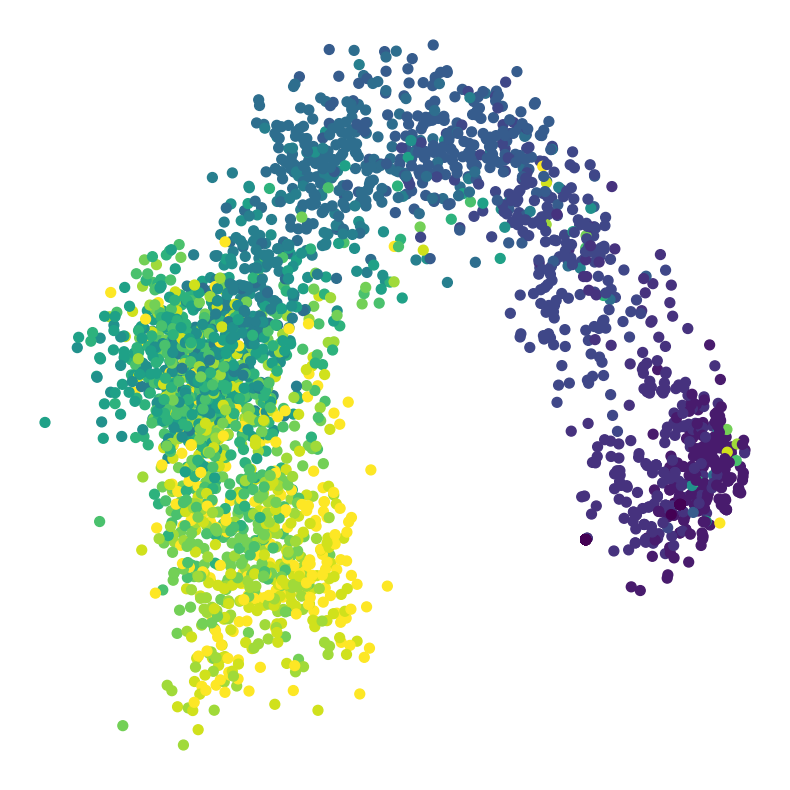

In [ ]:
for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        print(model_name)
        pca_embedding = pca_embeddings[model_name][dataset_name]
        times = [int(t) for t in timepoints[model_name][dataset_name]]

        df_plot = pd.DataFrame({
            "PCA_1": pca_embedding[:, 0],
            "PCA_2": pca_embedding[:, 1],
            "Timepoint": times
        })

        plt.figure(figsize=(8, 8))

        norm = mcolors.Normalize(vmin=min(times), vmax=max(times))
        cmap = cm.get_cmap("viridis")

        scatter = plt.scatter(
            df_plot["PCA_1"], df_plot["PCA_2"],
            c=df_plot["Timepoint"],
            cmap=cmap,
            norm=norm,
            s=50
        )

        # cbar = plt.colorbar(scatter)
        # cbar.set_ticks([])           
        # cbar.ax.tick_params(length=0) 
        # cbar.ax.set_yticklabels([])

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('')
        plt.ylabel('')
        plt.title('')

        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_visible(False)

        plt.tight_layout()
        plt.show()

In [ ]:
processed_pca = {}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        if dataset_name in processed_pca:
            continue
        else:
            processed_pca[dataset_name] = {}

            train_loader = data_loaders[dataset_name]["train"]
            test_loader = data_loaders[dataset_name]["test"]

            encoder = model.encoder
            last_layer = encoder[-1]
            dim = last_layer.out_features
            
            train_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in train_loader
            ]

            test_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in test_loader
            ]
        
            pca = PCA(n_components=dim)
            train_pca_images = pca.fit_transform(train_images)
            reconstructed_train_images = pca.inverse_transform(train_pca_images)

            test_pca_images = pca.transform(test_images)
            reconstructed_test_images = pca.inverse_transform(test_pca_images)

            train_mse = mean_squared_error(train_images, reconstructed_train_images)
            test_mse = mean_squared_error(test_images, reconstructed_test_images)

            processed_pca[dataset_name]["train"] = train_mse
            processed_pca[dataset_name]["test"] = test_mse

In [ ]:
# nn_reconstructions = {}

# for model_name, dataset in all_models.items():
#     nn_reconstructions[model_name] = {}
#     for dataset_name, model in dataset.items():
#         print(f'{model_name} | {dataset_name}')

#         embeddings = nn_embeddings[model_name][dataset_name]
#         model.eval()
#         with torch.no_grad():
#             reconstructed_samples = model.decode_image(embeddings)
#         reconstructed_samples = reconstructed_samples.reshape(-1, 128 * 128)
        
#         test_loader = data_loaders[dataset_name]["test"]
#         test_images = np.concatenate(
#             [batch[0].numpy().reshape(len(batch[0]), -1) for batch in test_loader],
#             axis=0
#         )
        
#         test_mse = mean_squared_error(test_images, reconstructed_samples)

#         nn_reconstructions[model_name][dataset_name] = test_mse

# print("Reconstruction MSE")
# print(f"{'Model':<15} {'Dataset':<20} {'Test MSE':<15}")
# print("-" * 65)
# for dataset_name, mse in processed_pca.items():
#     print(f"{'PCA':<20} {dataset_name:<20} {mse['test']:<15.6f}")

# for model_name, model_results in nn_reconstructions.items():
#     for dataset_name, mse in model_results.items():
#         print(f"{model_name:<20} {dataset_name:<20} {mse:<15.6f}")

## Latent dimension distributions

Plotting distributions for ae-medium | vascular_function_128


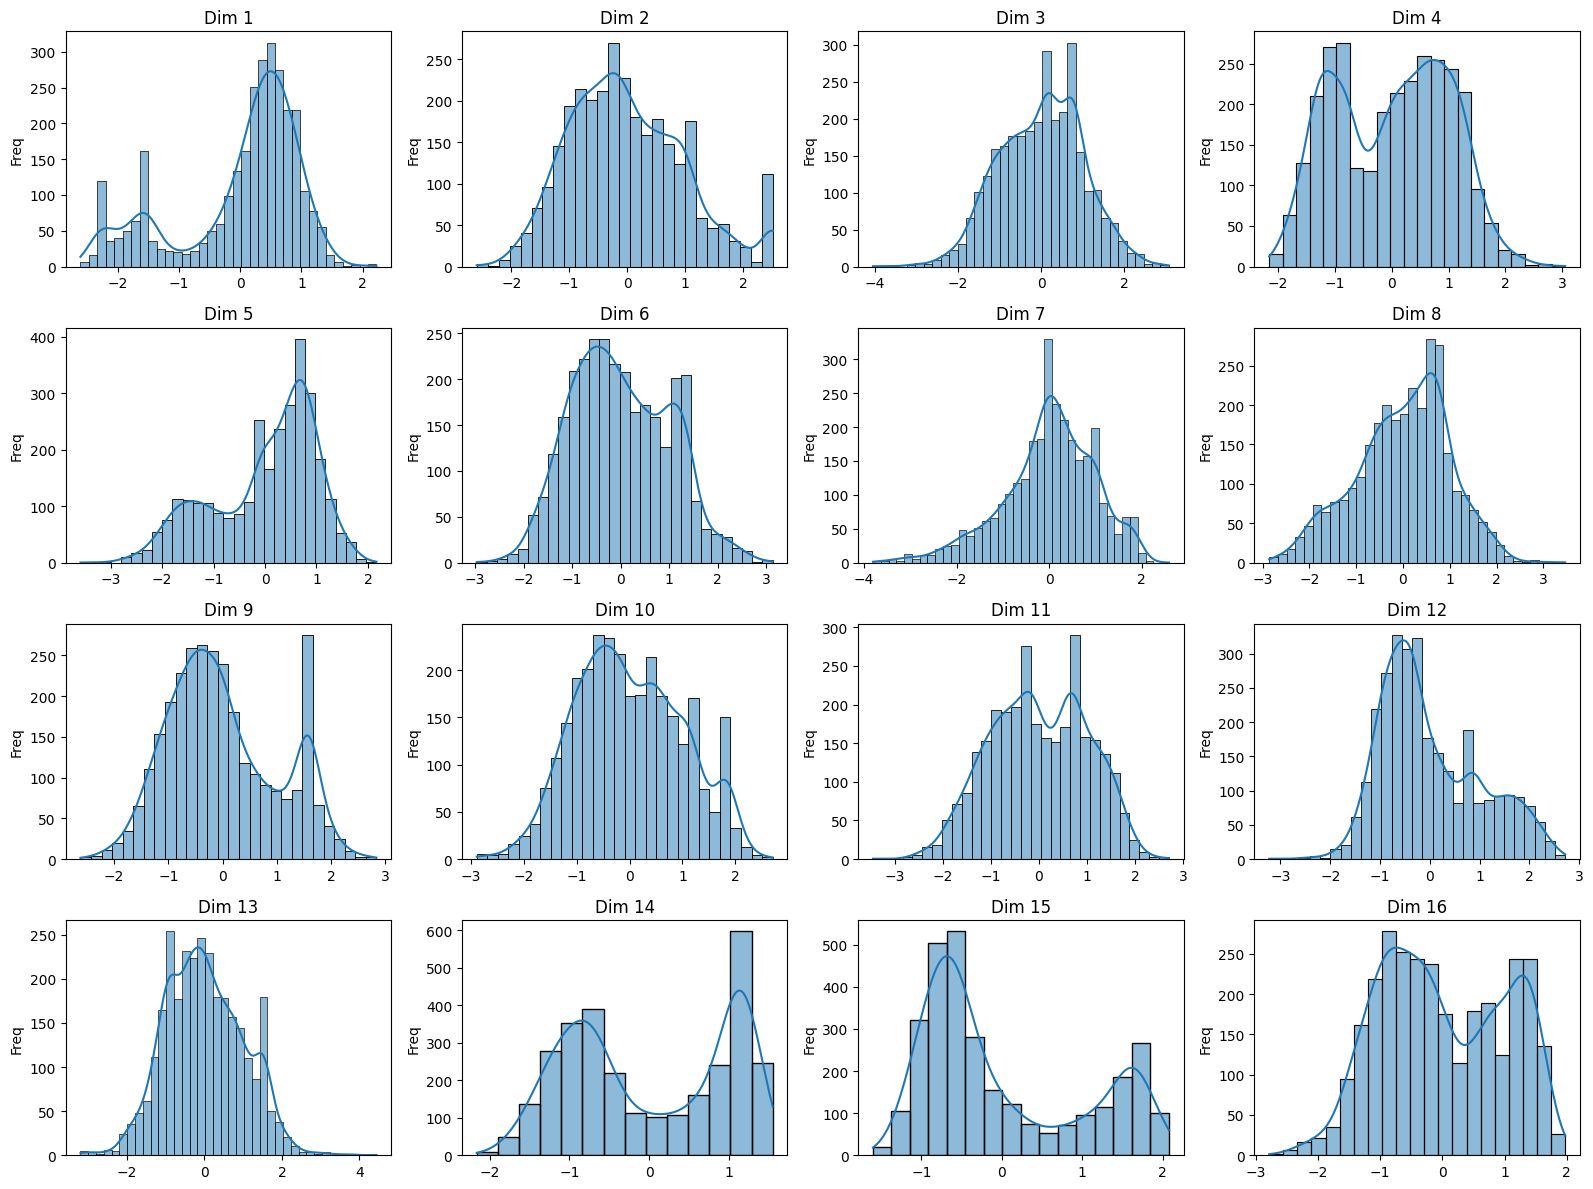

Plotting distributions for ae-small | vascular_function_128


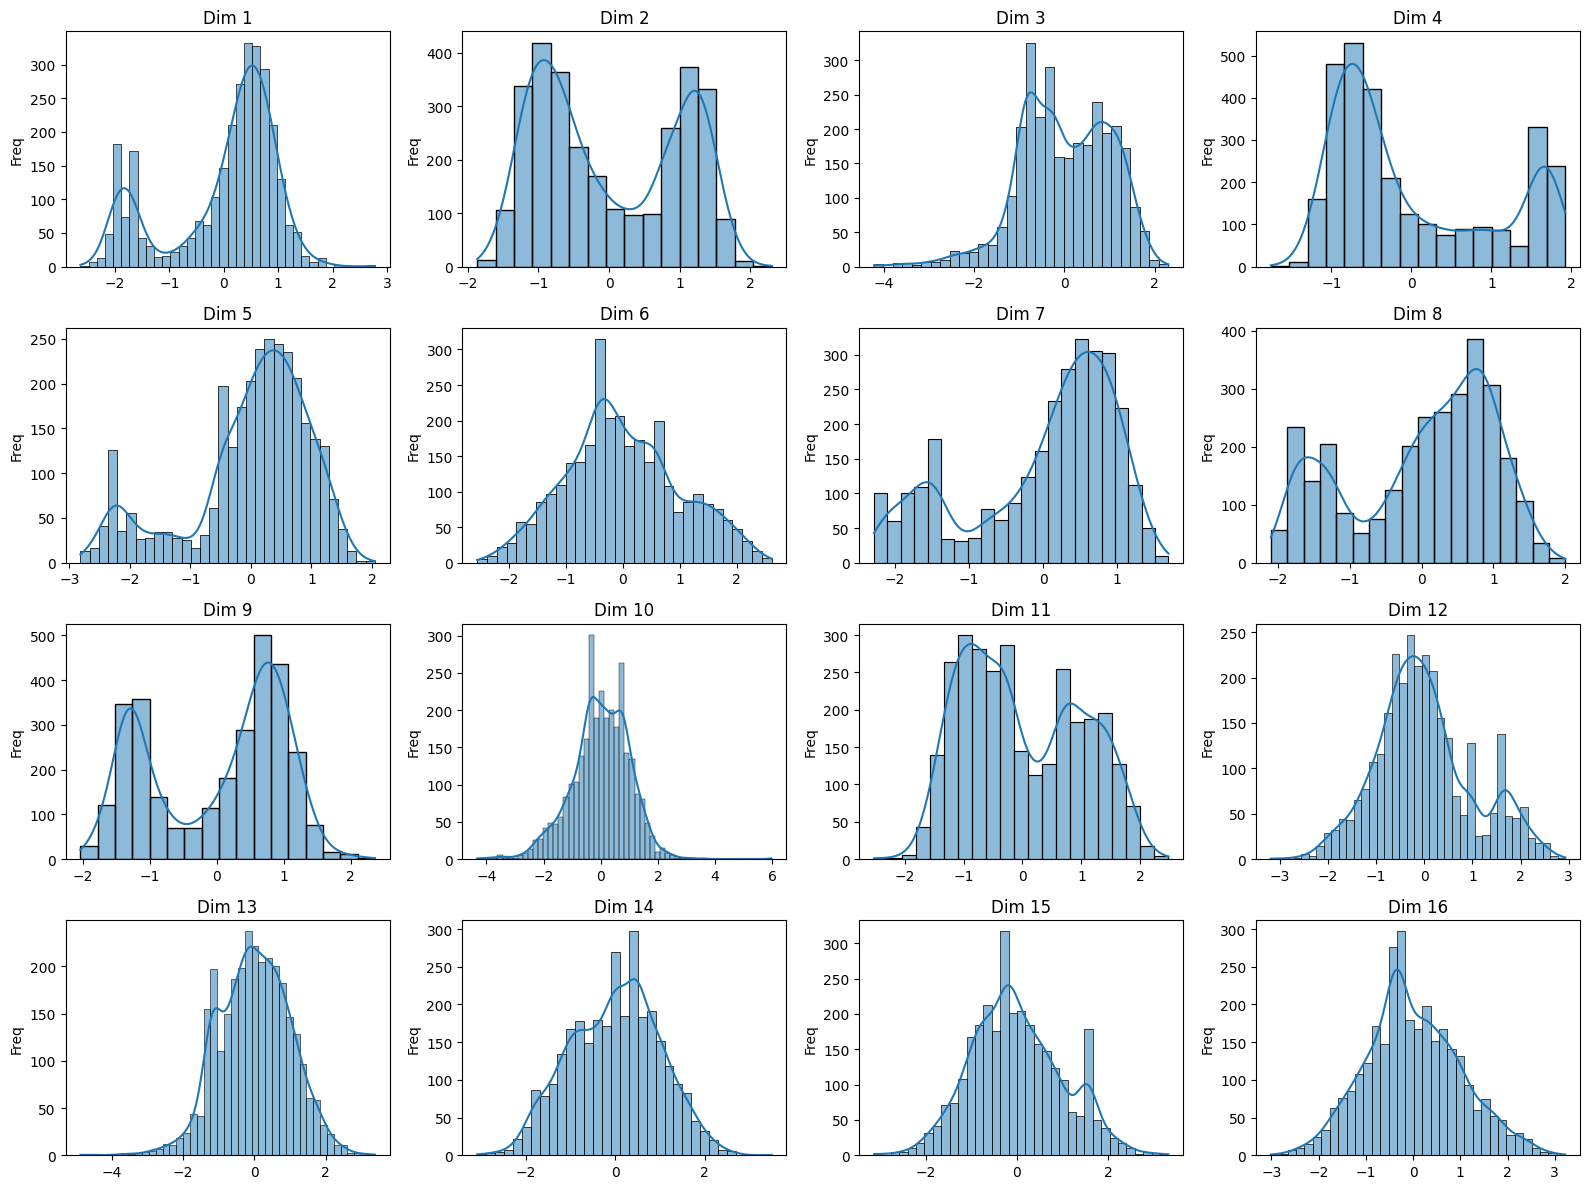

In [ ]:
for model_name, dataset in nn_embeddings.items():
    for dataset_name, embeddings in dataset.items():
        num_dimensions = embeddings.shape[1]
            
        if num_dimensions > 32:
            print(f"Skipping {model_name} | {dataset_name} due to large latent space size ({num_dimensions} dimensions)")
            continue

        print(f"Plotting distributions for {model_name} | {dataset_name}")

        cols = 4
        rows = int(np.ceil(num_dimensions / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
        axes = axes.flatten()

        for dim_idx in range(num_dimensions):
            sns.histplot(
                embeddings[:, dim_idx],
                ax=axes[dim_idx],
                kde=True,            
                bins="auto",        
            )
            axes[dim_idx].set_title(f"Dim {dim_idx + 1}")
            axes[dim_idx].set_xlabel("")
            axes[dim_idx].set_ylabel("Freq")

        for ax in axes[num_dimensions:]:
            ax.remove()

        plt.tight_layout()
        plt.show()

In [ ]:
# Scan through real image latent space
# for model_name, dataset in all_models.items():
#     for dataset_name, model in dataset.items():
#         embeddings = nn_embeddings[model_name][dataset_name]
#         loader = data_loaders[dataset_name]["full"]
#         num_dimensions = embeddings.shape[1]

#         test_indices = loader._test_indices
#         sample_ids = []
#         dimension_data = [] # List to hold (sample_id, embedding_vector)
#         for idx in test_indices:
#             sample_id = loader._get_data_feature(idx, 'sample_id')
#             sample_ids.append(sample_id)

        # for test_idx in range(len(test_indices)):
        #     full_dataset_idx = test_indices[test_idx]
        #     embedding_vector = embeddings[test_idx]
        #     sample_id = loader._get_data_feature(full_dataset_idx, 'sample_id')
        #     dimension_data.append({'sample_id': sample_id, 'embedding': embedding_vector})

        # for dim_idx in range(num_dimensions):
        #     dimension_values = sorted(dimension_data, key=lambda x: x["embedding"][dim_idx])

        #     min_sample = dimension_values[0]
        #     max_sample = dimension_values[-1]
        #     median_idx = len(dimension_values) // 2
        #     median_sample = dimension_values[median_idx]

        #     fig, axes = plt.subplots(1, 3, figsize=(6,6))
        #     for test_idx in range(len(test_indices)):
            #     full_dataset_idx = test_indices[test_idx]
            #     sample_id = loader._get_data_feature(full_dataset_idx, 'sample_id')
            #     if sample_id == min_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[0].imshow(image.squeeze(), cmap="gray")
            #             axes[0].axis('off')
            #             axes[0].set_title(f"{sample_id}")
            #     if sample_id == median_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[1].imshow(image.squeeze(), cmap="gray")
            #             axes[1].axis('off')
            #             axes[1].set_title(f"{sample_id}")
            #     if sample_id == max_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[2].imshow(image.squeeze(), cmap="gray")
            #             axes[2].axis('off')
            #             axes[2].set_title(f"{sample_id}")

            # plt.tight_layout()
            # plt.show()
        

In [ ]:
# for model_name, dataset in nn_embeddings.items():
#     for dataset_name, embeddings in dataset.items():
#         num_dimensions = embeddings.shape[1]
            
#         if num_dimensions >= 32:
#             print(f"Skipping {model_name} | {dataset_name} due to large latent space size ({num_dimensions} dimensions)")
#             continue

#         df = pd.DataFrame(embeddings, columns=[f"Dimension {j+1}" for j in range(num_dimensions)])
#         df["timepoint"] = timepoints[model_name][dataset_name]
        
#         print(f"Plotting for {model_name} | {dataset_name}")
        
#         g = sns.pairplot(df, hue="timepoint", palette="viridis", plot_kws={"s": 15}, corner=True)
#         g._legend.remove()
#         plt.tight_layout()
#         plt.show()

In [ ]:
sample_ids = defaultdict(lambda: defaultdict(list))

for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        
        loader = data_loaders[dataset_name]["full"]
        for i, idx in enumerate(loader._test_indices):
            sample_id = loader._get_data_feature(idx, 'sample_id')
            sample_ids[model_name][dataset_name].append(sample_id)

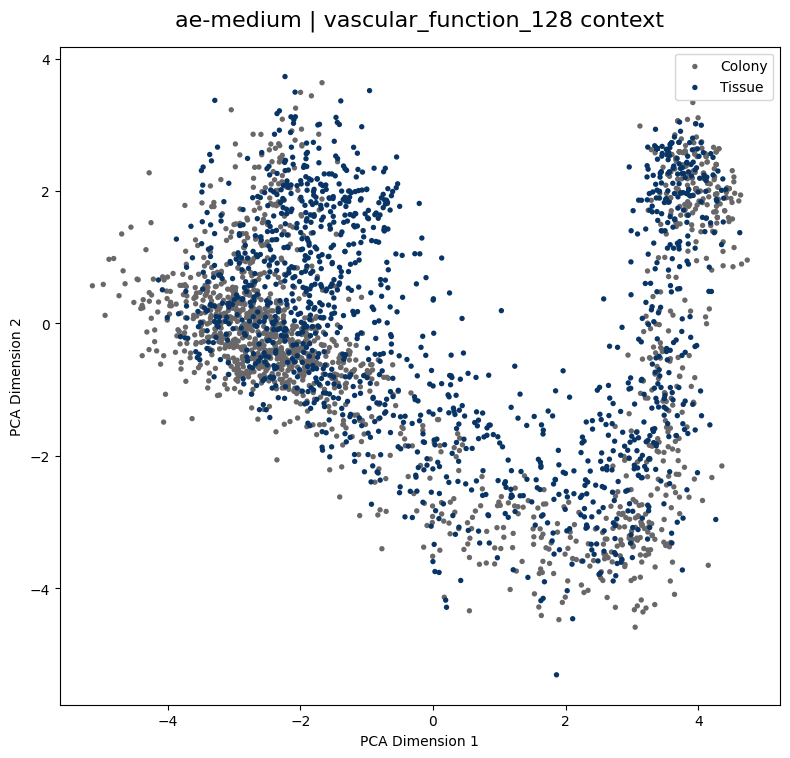

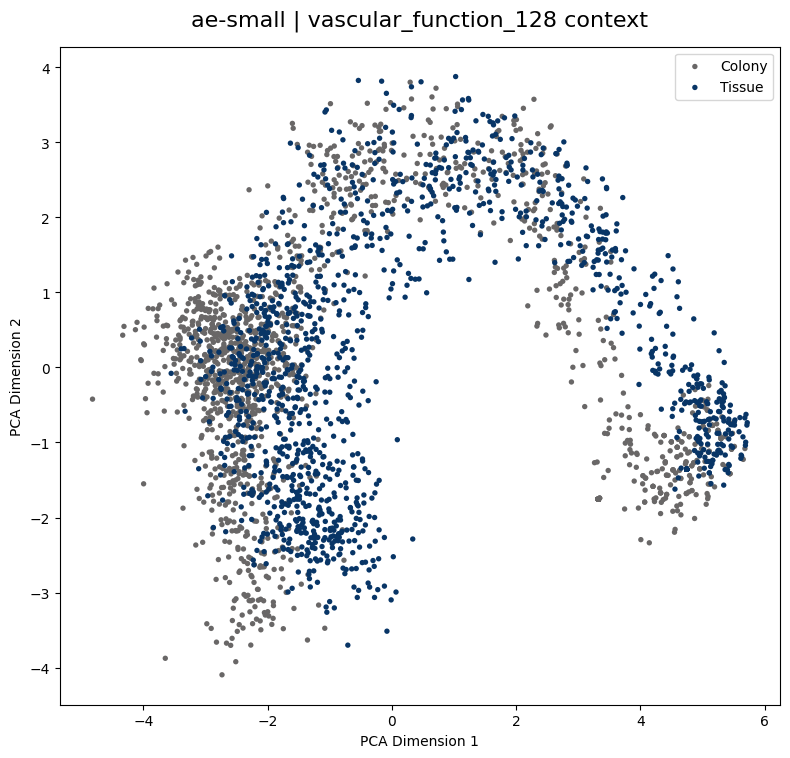

In [ ]:
base_colors = {1: "#696767", 2: "#083566"}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        current_sample_ids = sample_ids[model_name][dataset_name]

        array1_indices = [i for i, sid in enumerate(current_sample_ids) if sid.startswith('C_')]
        array2_indices = [i for i, sid in enumerate(current_sample_ids) if sid.startswith('CH')]

        fig, ax = plt.subplots(figsize=(8, 8))
        sns.scatterplot(x=pca_embedding[array1_indices, 0], y=pca_embedding[array1_indices, 1],
            ax=ax, color=base_colors[1], s=15, label='Colony', edgecolor='none')
        sns.scatterplot(x=pca_embedding[array2_indices, 0], y=pca_embedding[array2_indices, 1],
            ax=ax, color=base_colors[2], s=15, label='Tissue', edgecolor='none')

        ax.grid(False)
        ax.set_title(f'{model_name} | {dataset_name} context', fontsize=16, y=1.02)
        ax.set_xlabel('PCA Dimension 1')
        ax.set_ylabel('PCA Dimension 2')

        ax.legend(loc='upper right')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

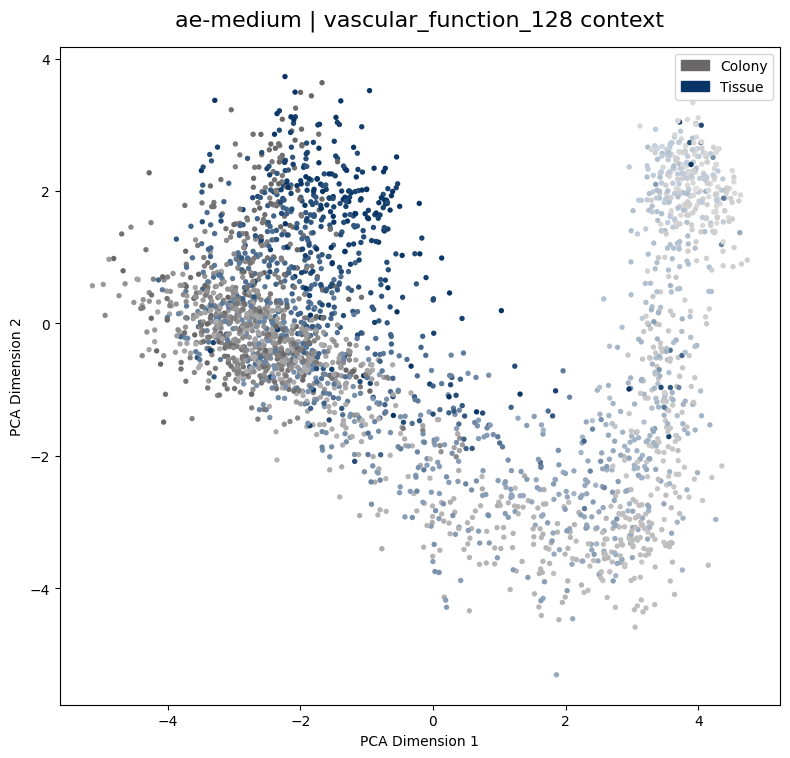

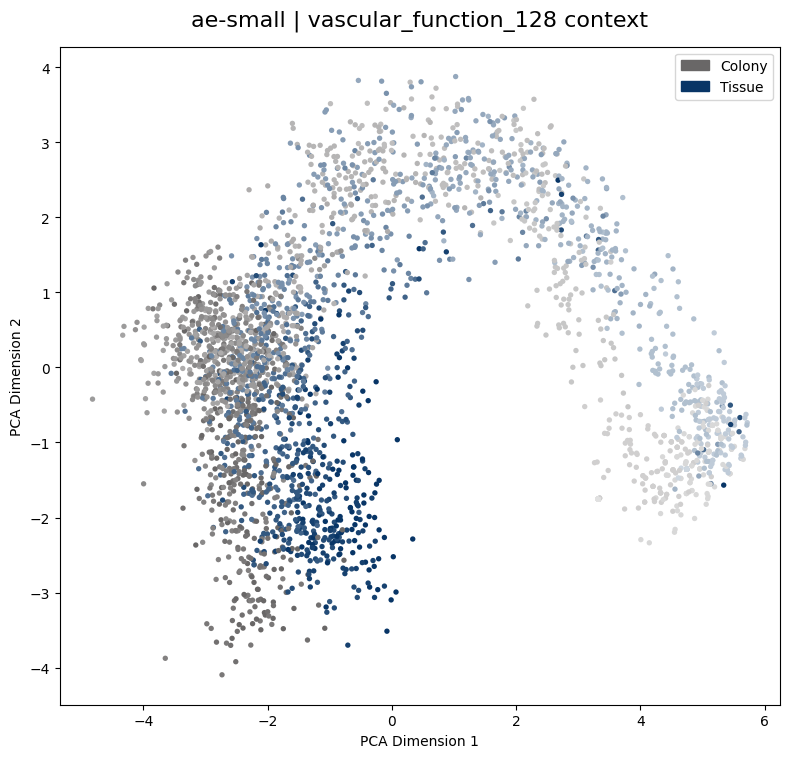

In [ ]:
def get_shaded_color(base_hex, timepoint, min_tp, max_tp, light_factor=0.2):
    base_rgb = hex2color(base_hex)
    if max_tp == min_tp:
        normalized_tp = 1.0
    else:
        normalized_tp = (timepoint - min_tp) / (max_tp - min_tp)
    interpolation_amount = light_factor + normalized_tp * (1 - light_factor)

    shaded_rgb = [1.0 * (1 - interpolation_amount) + c * interpolation_amount for c in base_rgb]
    shaded_rgb = [max(0, min(1, c)) for c in shaded_rgb]
    return shaded_rgb

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():

        pca_embedding = pca_embeddings[model_name][dataset_name]
        current_sample_ids = sample_ids[model_name][dataset_name]
        current_timepoints = timepoints[model_name][dataset_name]

        min_timepoint = min(current_timepoints)
        max_timepoint = max(current_timepoints)

        point_colors = []
        arrays_in_plot = set()

        for i in range(len(pca_embedding)):
            sid = current_sample_ids[i]
            tp = current_timepoints[i]

            base_hex = None
            if sid.startswith('C_'):
                base_hex = base_colors[1]
                arrays_in_plot.add(1)
            elif sid.startswith('CH'):
                base_hex = base_colors[2]
                arrays_in_plot.add(2)

            shaded_color_rgb = get_shaded_color(base_hex, tp, min_timepoint, max_timepoint)
            point_colors.append(shaded_color_rgb)

        fig, ax = plt.subplots(figsize=(8, 8))
        sns.scatterplot(x=pca_embedding[:, 0], y=pca_embedding[:, 1],
                        ax=ax,
                        c=point_colors,
                        s=15, edgecolor='none')

        ax.grid(False)

        ax.set_title(f'{model_name} | {dataset_name} context', fontsize=16, y=1.02)
        ax.set_xlabel('PCA Dimension 1')
        ax.set_ylabel('PCA Dimension 2')

        legend_handles = []
        if 1 in arrays_in_plot:
            legend_handles.append(mpatches.Patch(color=base_colors[1], label='Colony'))
        if 2 in arrays_in_plot:
            legend_handles.append(mpatches.Patch(color=base_colors[2], label='Tissue'))

        ax.legend(handles=legend_handles, loc='upper right')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


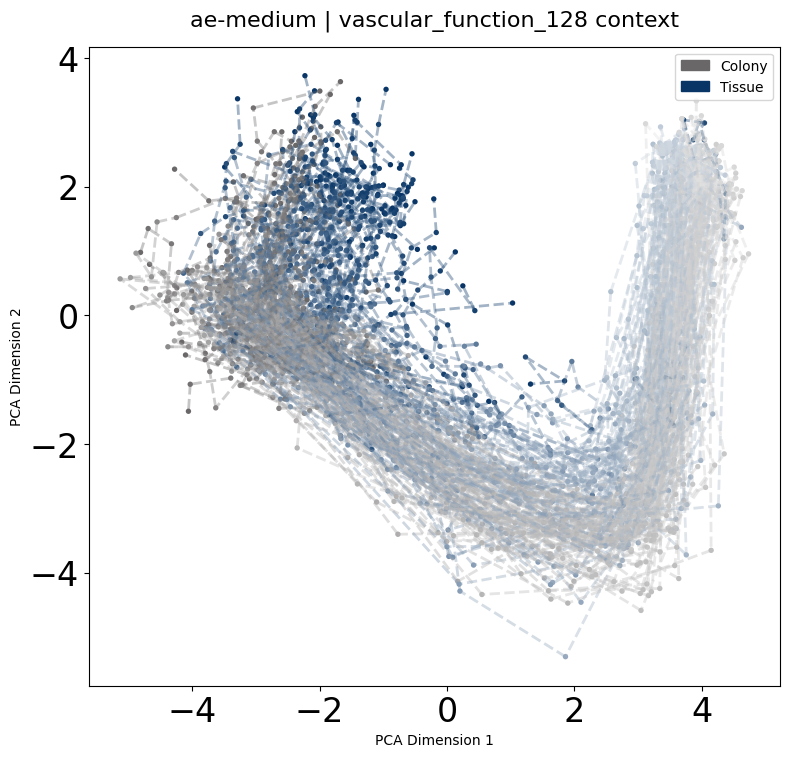

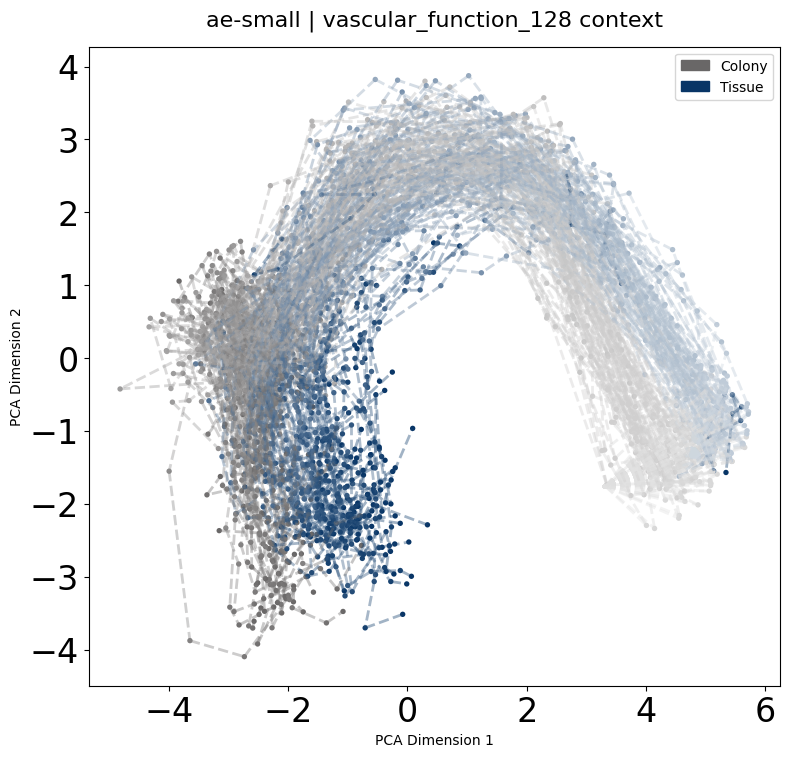

In [ ]:
for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():

        pca_embedding = pca_embeddings[model_name][dataset_name]
        current_sample_ids = sample_ids[model_name][dataset_name]
        current_timepoints = timepoints[model_name][dataset_name]

        min_timepoint = min(current_timepoints)
        max_timepoint = max(current_timepoints)

        point_colors = []
        arrays_in_plot = set()
        trajectory_data = defaultdict(list)

        for i in range(len(pca_embedding)):
            sid = current_sample_ids[i]
            tp = current_timepoints[i]
            embedding = pca_embedding[i, :]

            base_hex = None
            if sid.startswith('C_'):
                base_hex = base_colors[1]
                arrays_in_plot.add(1)
            elif sid.startswith('CH'):
                base_hex = base_colors[2]
                arrays_in_plot.add(2)

            if base_hex:
                shaded_color_rgb = get_shaded_color(base_hex, tp, min_timepoint, max_timepoint)
                point_colors.append(shaded_color_rgb)
                trajectory_data[sid].append((tp, embedding, shaded_color_rgb))
            else:
                 point_colors.append("gray")

        fig, ax = plt.subplots(figsize=(8, 8))

        sns.scatterplot(x=pca_embedding[:, 0], y=pca_embedding[:, 1],
                        ax=ax,
                        c=point_colors,
                        s=15, edgecolor='none')

        for sid, trajectory_list in trajectory_data.items():
            trajectory_list.sort(key=lambda x: x[0])

            for j in range(len(trajectory_list) - 1):
                start_tp, start_embedding, start_color = trajectory_list[j]
                end_tp, end_embedding, end_color = trajectory_list[j+1]

                ax.plot([start_embedding[0], end_embedding[0]],
                        [start_embedding[1], end_embedding[1]],
                        color=start_color,
                        linestyle='--',
                        linewidth=2.0,
                        alpha=0.4)

        ax.grid(False)

        ax.set_title(f'{model_name} | {dataset_name} context', fontsize=16, y=1.02)
        ax.set_xlabel('PCA Dimension 1')
        ax.set_ylabel('PCA Dimension 2')
        ax.tick_params(axis='x', labelsize=24)
        ax.tick_params(axis='y', labelsize=24)

        legend_handles = []
        if 1 in arrays_in_plot:
            legend_handles.append(mpatches.Patch(color=base_colors[1], label='Colony'))
        if 2 in arrays_in_plot:
            legend_handles.append(mpatches.Patch(color=base_colors[2], label='Tissue'))

        

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig(f"figures/gastruloid/gastruloid_{model_name}_combined_trajectories.png")
        if legend_handles:
            ax.legend(handles=legend_handles, loc='upper right')
        plt.show()

ae-medium


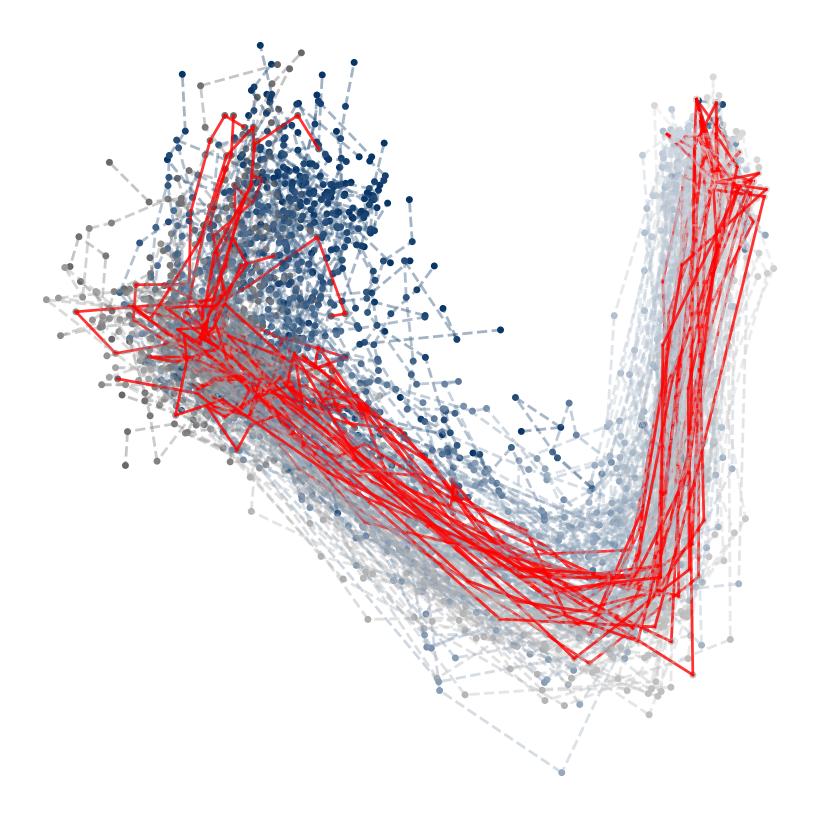

ae-small


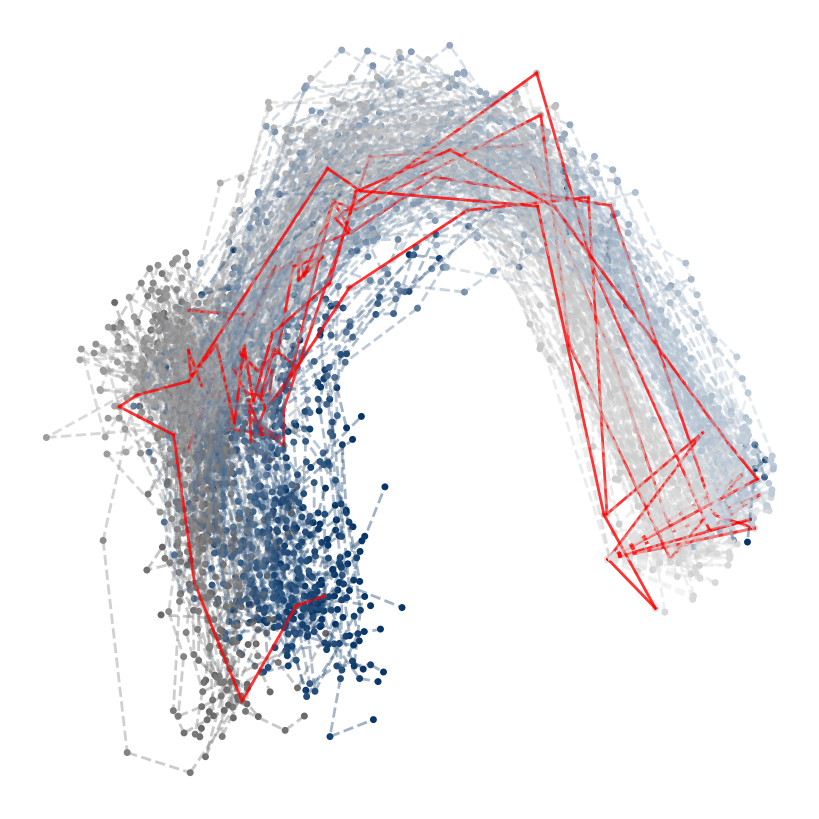

In [ ]:
classification_file = f"results_downstream/{study_name}_classification_results.json"
incorrect_samples = defaultdict(lambda: defaultdict(list))
try:
    with open(classification_file, "r") as f:
        classification_results = json.load(f)

    for item in classification_results["model_dataset_results"]:
        incorrect_samples[item["model_name"]][item["dataset_name"]] = item["incorrect_predictions"]

    for model_name, datasets in all_models.items():
        print(model_name)
        for dataset_name, model in datasets.items():
            emb = pca_embeddings[model_name][dataset_name]
            ids = sample_ids[model_name][dataset_name]
            tps = timepoints[model_name][dataset_name]
            incorrect = set(incorrect_samples[model_name][dataset_name])

            tmin, tmax = min(tps), max(tps)
            col = []; traj = defaultdict(list)

            for i, (sid, tp) in enumerate(zip(ids, tps)):
                base = 1 if sid.startswith('C_') else \
                       2 if sid.startswith('CH_') else None
                if base:
                    color = get_shaded_color(base_colors[base], tp, tmin, tmax)
                    col.append(color)
                    traj[sid].append((tp, emb[i], color))
                else:
                    col.append("gray")

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.scatter(emb[:, 0], emb[:, 1], c=col, s=25, edgecolor='none')

            for sid, entries in traj.items():
                entries.sort(key=lambda x: x[0])
                for (_, e1, c1), (_, e2, _) in zip(entries, entries[1:]):
                    ax.plot([e1[0], e2[0]], [e1[1], e2[1]],
                            color='red' if sid in incorrect else c1,
                            linestyle='-' if sid in incorrect else '--',
                            linewidth=2.0 if sid in incorrect else 2.0,
                            alpha=0.8 if sid in incorrect else 0.4)

            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(''); ax.set_ylabel('')
            ax.set_title('')
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)

            plt.tight_layout(pad=0)
            plt.savefig(f"figures/ARCADE/ARCADE_{model_name}_combined_trajectories_incorrect.png", dpi=300, bbox_inches='tight', pad_inches=0)
            plt.show()

except FileNotFoundError:
    print(f"[Warning] missing file: {classification_file}")
except Exception as e:
    print(f"[Error] {e}")

ae-medium


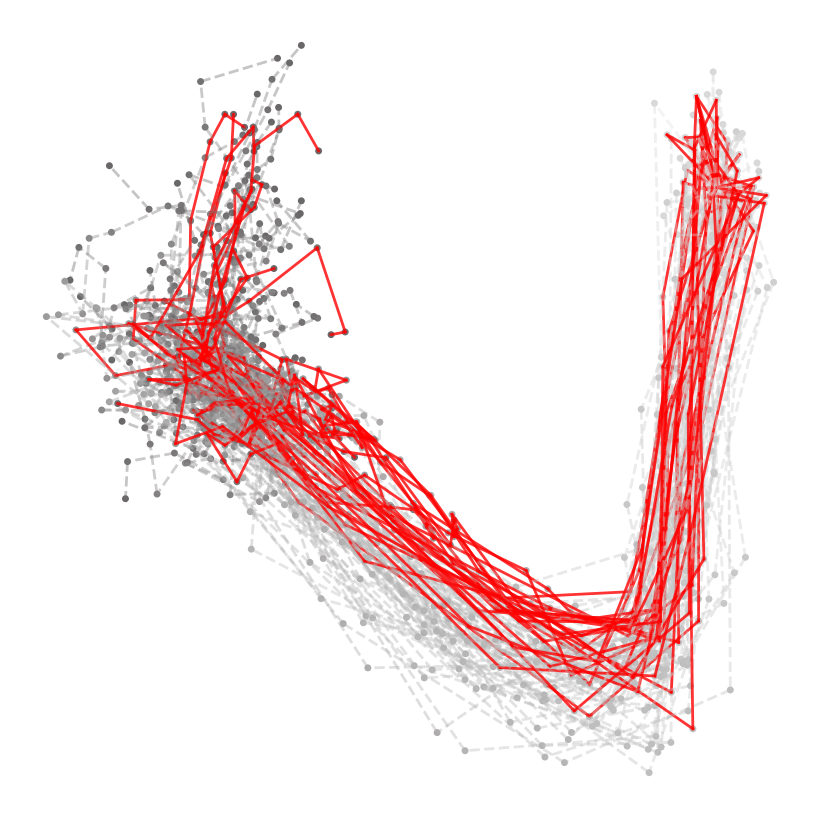

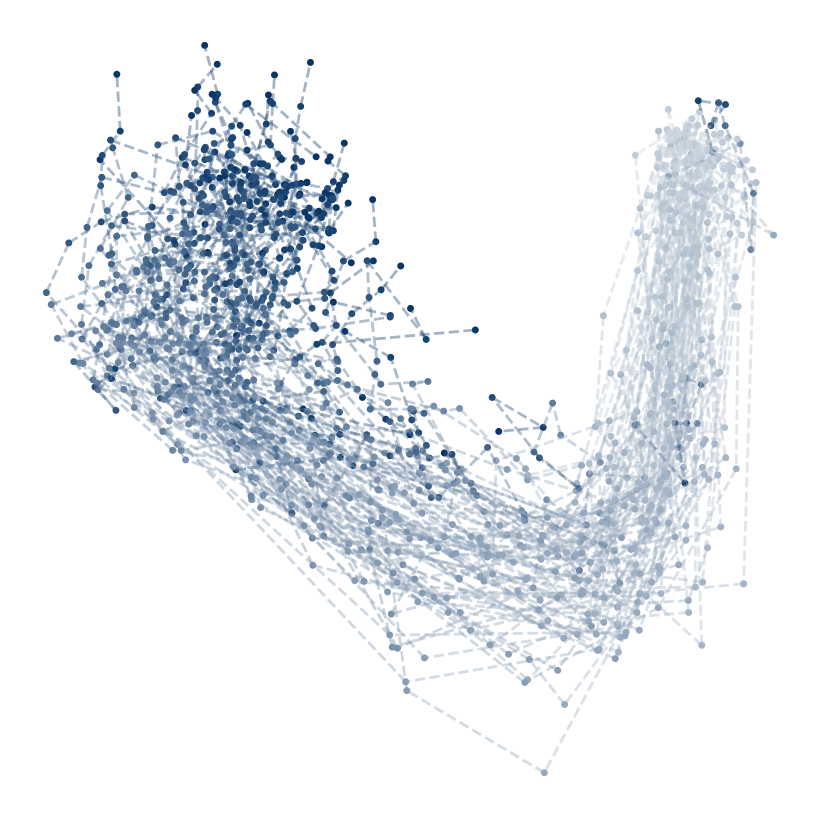

ae-small


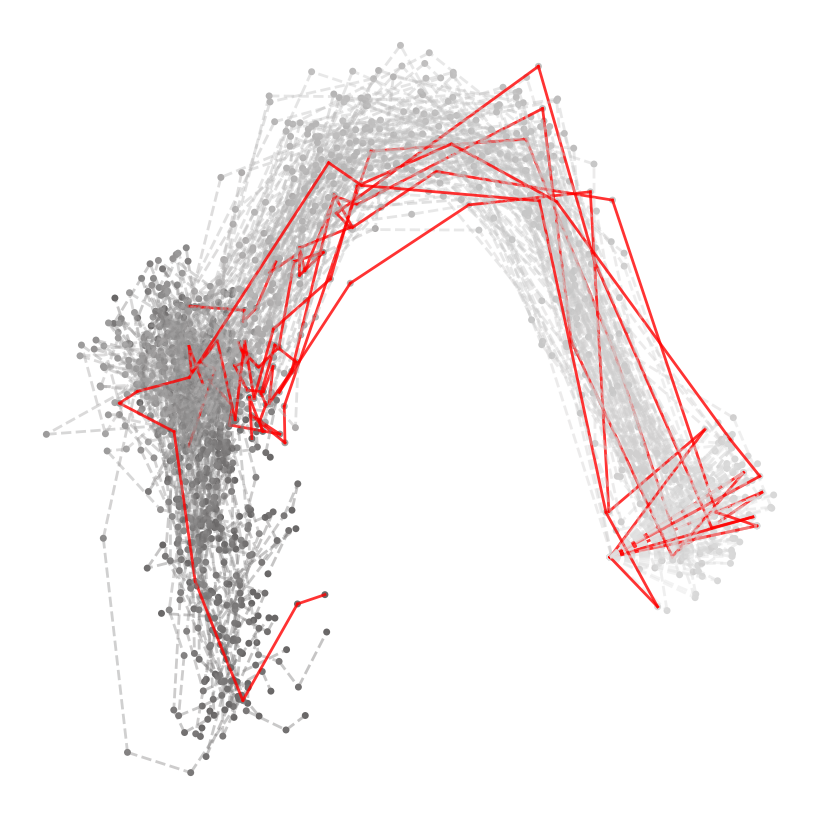

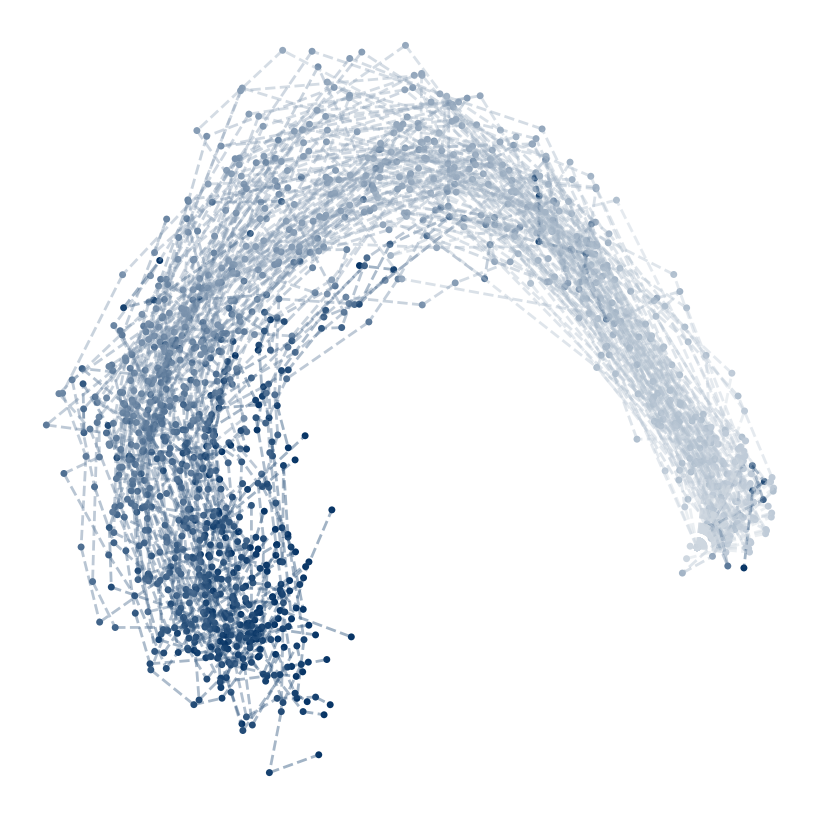

In [ ]:
for model_name, datasets in all_models.items():
    print(model_name)
    for dataset_name, model in datasets.items():
        emb = pca_embeddings[model_name][dataset_name]
        ids = sample_ids[model_name][dataset_name]
        tps = timepoints[model_name][dataset_name]
        incorrect = set(incorrect_samples[model_name][dataset_name])

        tmin, tmax = min(tps), max(tps)

        data_by_type = {1: {'emb': [], 'col': [], 'traj': defaultdict(list)},
                        2: {'emb': [], 'col': [], 'traj': defaultdict(list)}}

        for i, (sid, tp) in enumerate(zip(ids, tps)):
            base = 1 if sid.startswith("C_") else \
                   2 if sid.startswith("CH_") else None
            if base:
                shade = get_shaded_color(base_colors[base], tp, tmin, tmax)
                data_by_type[base]['emb'].append(emb[i])
                data_by_type[base]['col'].append(shade)
                data_by_type[base]['traj'][sid].append((tp, emb[i], shade))

        for array_type, label in zip([1, 2], ['C', 'CH']):
            emb_array = np.array(data_by_type[array_type]['emb'])
            col_array = data_by_type[array_type]['col']
            traj_dict = data_by_type[array_type]['traj']

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.scatter(emb_array[:, 0], emb_array[:, 1], c=col_array, s=25, edgecolor='none')

            for sid, entries in traj_dict.items():
                entries.sort(key=lambda x: x[0])
                for (_, e1, c1), (_, e2, _) in zip(entries, entries[1:]):
                    ax.plot([e1[0], e2[0]], [e1[1], e2[1]],
                            color='red' if sid in incorrect else c1,
                            linestyle='-' if sid in incorrect else '--',
                            linewidth=2.0 if sid in incorrect else 2.0,
                            alpha=0.8 if sid in incorrect else 0.4)

            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title('')
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)

            plt.tight_layout(pad=0)
            plt.savefig(f"figures/ARCADE/ARCADE_{model_name}_{label}_trajectories.png",
                        dpi=300, bbox_inches='tight', pad_inches=0)
            plt.show()